1. What are the most demanded skills for the top 3 most popular data roles?  

In [1]:
# Importing Libraries
import ast
import pandas as pd
import seaborn as sns
from datasets import load_dataset
import matplotlib.pyplot as plt

In [2]:
#Load Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

In [3]:
#Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [4]:
#Limit data to Malaysia
df_my = df[df['job_country']=='Malaysia']

In [6]:
df_skills = df_my.explode('job_skills')

df_skills[['job_title_short', 'job_skills']]

,job_title_short,job_skills
47,Senior Data Engineer,sql
47,Senior Data Engineer,python
47,Senior Data Engineer,scala
47,Senior Data Engineer,nosql
47,Senior Data Engineer,java
...,...,...
785662,Business Analyst,powerpoint
785662,Business Analyst,visio
785677,Cloud Engineer,None
785738,Business Analyst,powerpoint


In [13]:
df_skills_count = df_skills.groupby(['job_skills', 'job_title_short']).size()
df_skills_count = df_skills_count.reset_index(name='skill_count')
df_skills_count.sort_values(by='skill_count', ascending=False, inplace=True)
df_skills_count

,job_skills,job_title_short,skill_count
977,sql,Data Analyst,1095
272,excel,Data Analyst,1022
763,python,Data Scientist,830
978,sql,Data Engineer,799
761,python,Data Analyst,738
...,...,...,...
1033,t-sql,Cloud Engineer,1
356,gitlab,Business Analyst,1
351,github,Machine Learning Engineer,1
686,perl,Senior Data Scientist,1


In [39]:
#get top 3 data roles in Malaysia
top3_job_titles = df_skills_count['job_title_short'].unique().tolist()
top3_job_titles = sorted(top3_job_titles[:3])
top3_job_titles

['Data Analyst', 'Data Engineer', 'Data Scientist']

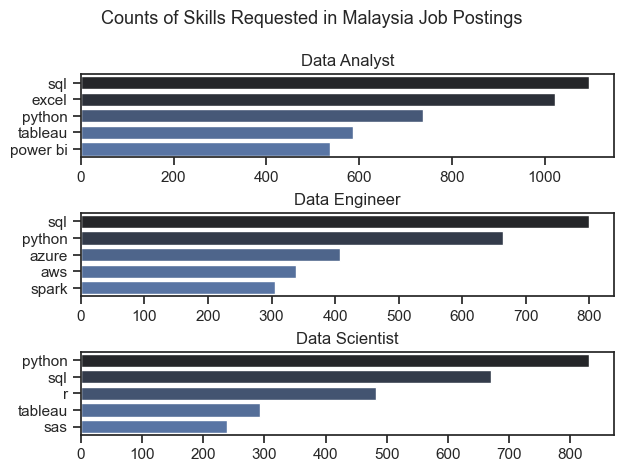

In [ ]:
22233333222222

In [25]:
df_job_title_count = df_my['job_title_short'].value_counts().reset_index(name='jobs_total')

In [29]:
#merge total count to skill count
df_skills_perc = pd.merge(df_skills_count, df_job_title_count, how='left', on='job_title_short')
df_skills_perc['skill_percent'] = 100* df_skills_perc['skill_count']/df_skills_perc['jobs_total']
df_skills_perc


,job_skills,job_title_short,skill_count,jobs_total,skill_percent
0,sql,Data Analyst,1095,2527,43.332014
1,excel,Data Analyst,1022,2527,40.443213
2,python,Data Scientist,830,1491,55.667337
3,sql,Data Engineer,799,1404,56.908832
4,python,Data Analyst,738,2527,29.204590
...,...,...,...,...,...
1175,t-sql,Cloud Engineer,1,258,0.387597
1176,gitlab,Business Analyst,1,1320,0.075758
1177,github,Machine Learning Engineer,1,163,0.613497
1178,perl,Senior Data Scientist,1,281,0.355872


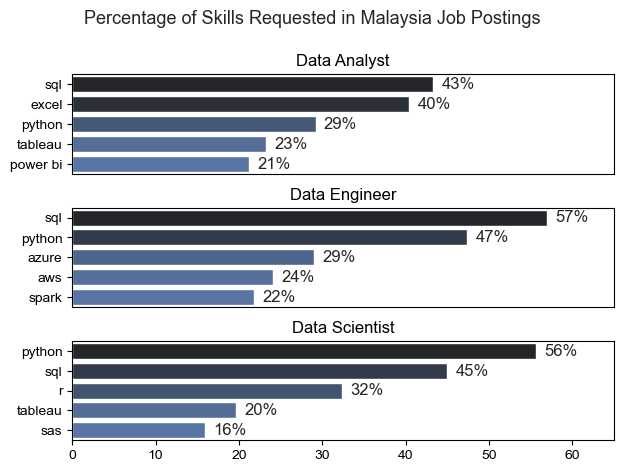

In [56]:
fig,ax = plt.subplots(len(top3_job_titles), 1)

sns.set_theme(style='ticks')
for i, job_title in enumerate(top3_job_titles):
    df_plot = df_skills_perc[df_skills_perc['job_title_short'] == job_title].head(5)
    sns.barplot(data=df_plot, x='skill_percent', y='job_skills', ax=ax[i], hue='skill_count', palette='dark:b_r')
    ax[i].set_title(job_title)
    ax[i].set_ylabel('')
    ax[i].set_xlabel('')
    ax[i].get_legend().remove()
    ax[i].set_xlim(0, 65)
    # remove the x-axis tick labels for better readability
    if i != len(job_titles) - 1:
        ax[i].set_xticks([])

    # label the percentage on the bars
    for n, v in enumerate(df_plot['skill_percent']):
        ax[i].text(v + 1, n, f'{v:.0f}%', va='center')

fig.suptitle('Percentage of Skills Requested in Malaysia Job Postings', fontsize=13)
fig.tight_layout(h_pad=0.8)